**2020~2022 기온 데이터로 2023 전력수요량 예측후 평가하기, 2024 전력수요량 예측하기**

In [ ]:
# 기본 라이브러리 불러오기

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2020~2024 전력수요량과 기온데이터 불러오기

df_elec1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/전력사용량_2020.csv", encoding='CP949')
df_elec2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/전력사용량_2021.csv", encoding='CP949')
df_elec3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/전력사용량_2022.csv", encoding='CP949')
df_elec4 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/전력사용량_2023.csv", encoding='CP949')
df_elec5 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/전력사용량_2024.csv", encoding='CP949')

df_gyeonggi = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/경기도기온.csv", encoding='CP949')

In [ ]:
# 데이터 구조 살펴보기

print(df_elec1.head(3))
print('\n')
print(df_gyeonggi.head(3))

         거래일자  거래시간   지역   전력거래량(MWh) 
0  2020-01-01     1  경기도         10777
1  2020-01-01     2  경기도          9254
2  2020-01-01     3  경기도          8272


   지점  지점명          일시  평균기온(°C)  최저기온(°C)  최고기온(°C)
0  98  동두천  2020-01-01      -3.8      -8.0       0.3
1  98  동두천  2020-01-02      -0.6      -3.8       3.2
2  98  동두천  2020-01-03      -2.1      -6.4       4.8


데이터 전처리

In [ ]:
# 경기도만 데이터 따로 수집

df_2020 = df_elec1[df_elec1['지역']=='경기도']
df_2021 = df_elec2[df_elec2['지역']=='경기도']
df_2022 = df_elec3[df_elec3['지역']=='경기도']
df_2023 = df_elec4[df_elec4['지역']=='경기도']
df_2024 = df_elec5[df_elec5['지역']=='경기도']

In [ ]:
# 칼럼 확인하기

print(df_2020.columns)
print(df_2021.columns)
print(df_2022.columns)
print(df_2023.columns)
print(df_2024.columns)

Index(['거래일자', '거래시간', '지역', ' 전력거래량(MWh) '], dtype='object')
Index(['거래일자', '거래시간', '지역', ' 전력거래량(MWh) '], dtype='object')
Index(['거래일자', '거래시간', '지역', ' 전력거래량(MWh) '], dtype='object')
Index(['거래일자', '거래시간', '지역', ' 전력거래량(MWh) '], dtype='object')
Index(['거래일자', '거래시간', '지역', '전력거래량(MWh)'], dtype='object')


In [ ]:
# 컬럼명 수정, 통일하기

df_2020.columns = df_2020.columns.str.strip()
df_2021.columns = df_2021.columns.str.strip()
df_2022.columns = df_2022.columns.str.strip()
df_2023.columns = df_2023.columns.str.strip()

In [ ]:
# 행방향 으로 2020~2024 전력데이터 합치기

df_g = pd.concat([df_2020,df_2021,df_2022,df_2023,df_2024],axis=0,ignore_index=True)

print(df_g.head(24))
print("\n")
print(df_g.tail(24))


          거래일자  거래시간   지역  전력거래량(MWh)
0   2020-01-01     1  경기도     10777.0
1   2020-01-01     2  경기도      9254.0
2   2020-01-01     3  경기도      8272.0
3   2020-01-01     4  경기도      8265.0
4   2020-01-01     5  경기도      8179.0
5   2020-01-01     6  경기도      8134.0
6   2020-01-01     7  경기도      7970.0
7   2020-01-01     8  경기도      7962.0
8   2020-01-01     9  경기도      7436.0
9   2020-01-01    10  경기도      6339.0
10  2020-01-01    11  경기도      5993.0
11  2020-01-01    12  경기도      5935.0
12  2020-01-01    13  경기도      6203.0
13  2020-01-01    14  경기도      6360.0
14  2020-01-01    15  경기도      6529.0
15  2020-01-01    16  경기도      6869.0
16  2020-01-01    17  경기도      7078.0
17  2020-01-01    18  경기도      8618.0
18  2020-01-01    19  경기도      9654.0
19  2020-01-01    20  경기도      9679.0
20  2020-01-01    21  경기도      9346.0
21  2020-01-01    22  경기도      9391.0
22  2020-01-01    23  경기도      9661.0
23  2020-01-01    24  경기도      9427.0


             거래일자  거래시간   지역    전력거래량(MWh)
43824

In [ ]:
# 정답데이터 1시간 단위(전력수요량) -> 일 단위로 바꾸기

df_g = df_g.groupby(df_g.index // 24).agg({
    '거래일자': 'first',
    '지역': 'first',
    '전력거래량(MWh)': 'mean'
}).reset_index(drop=True)

print(df_g)

            거래일자   지역    전력거래량(MWh)
0     2020-01-01  경기도   8055.458333
1     2020-01-02  경기도  12908.708333
2     2020-01-03  경기도  13093.291667
3     2020-01-04  경기도   9856.791667
4     2020-01-05  경기도   7518.541667
...          ...  ...           ...
1822  2024-12-27  경기도  12868.508070
1823  2024-12-28  경기도  10896.293024
1824  2024-12-29  경기도   9829.100620
1825  2024-12-30  경기도  11827.074391
1826  2024-12-31  경기도  12777.230993

[1827 rows x 3 columns]


In [ ]:
# 기온데이터 지점명 확인

print(df_gyeonggi['지점명'].unique())

['동두천' '파주' '수원' '양평' '이천']


In [ ]:
# 전력데이터와 기온데이터를 병합하기 위해서 컬럼명 통일

df_g = df_g.rename(columns={'거래일자':'일시'})

In [ ]:
# 전력데이터와 기온데이터 병합 하지만 문제 발생 -> 기온데이터의 ['동두천' '파주' '수원' '양평' '이천']
# 5개의 지점명 데이터떄문에 중복되는 데이터 발생

data = pd.merge(df_g, df_gyeonggi, on='일시')
data = data.drop(['지점','지점명'],axis=1)

print(data.columns)
print('\n\n')
print(data.head(25))

Index(['일시', '지역', '전력거래량(MWh)', '평균기온(°C)', '최저기온(°C)', '최고기온(°C)'], dtype='object')



            일시   지역    전력거래량(MWh)  평균기온(°C)  최저기온(°C)  최고기온(°C)
0   2020-01-01  경기도   8055.458333      -3.8      -8.0       0.3
1   2020-01-01  경기도   8055.458333      -4.0      -7.5       0.6
2   2020-01-01  경기도   8055.458333      -2.2      -6.3       0.3
3   2020-01-01  경기도   8055.458333      -3.8      -7.2      -1.3
4   2020-01-01  경기도   8055.458333      -4.2      -7.9      -2.0
5   2020-01-02  경기도  12908.708333      -0.6      -3.8       3.2
6   2020-01-02  경기도  12908.708333      -1.7      -5.1       3.2
7   2020-01-02  경기도  12908.708333       1.3      -0.3       3.2
8   2020-01-02  경기도  12908.708333      -0.4      -3.0       2.6
9   2020-01-02  경기도  12908.708333       0.0      -2.5       2.4
10  2020-01-03  경기도  13093.291667      -2.1      -6.4       4.8
11  2020-01-03  경기도  13093.291667      -3.5      -8.8       3.7
12  2020-01-03  경기도  13093.291667      -0.1      -3.9       5.2
13  2020-01-03 

In [ ]:
# 지점명 세부사항으로 인한 중복되는 데이터 통합 (['동두천' '파주' '수원' '양평' '이천'] -> 경기도)

data = data.groupby('일시').agg(
    지역=('지역', 'first'),
    전력거래량_MWh=('전력거래량(MWh)', 'first'),
    평균기온_C=('평균기온(°C)', 'mean'),
    최저기온_C=('최저기온(°C)', 'mean'),
    최고기온_C=('최고기온(°C)', 'mean')
).reset_index()


data = data.rename(columns={
    '전력거래량_MWh': '전력거래량(MWh)',
    '평균기온_C': '평균기온(°C)',
    '최저기온_C': '최저기온(°C)',
    '최고기온_C': '최고기온(°C)'
})

In [ ]:
# 최종 모든 데이터 확인 (데이터 구조,길이) 2020.01.01 ~ 2024.12.31 -> 1827일

data['전력거래량(MWh)'] = np.round(data['전력거래량(MWh)'],0)
print(data.head(5))
print('\n')
print(data.tail(5))
print('\n\n')
print('5년치 총 데이터: ',len(data))

           일시   지역  전력거래량(MWh)  평균기온(°C)  최저기온(°C)  최고기온(°C)
0  2020-01-01  경기도      8055.0     -3.60     -7.38     -0.42
1  2020-01-02  경기도     12909.0     -0.28     -2.94      2.92
2  2020-01-03  경기도     13093.0     -1.26     -5.90      5.08
3  2020-01-04  경기도      9857.0     -0.56     -6.66      6.98
4  2020-01-05  경기도      7519.0     -1.14     -7.42      5.66


              일시   지역  전력거래량(MWh)  평균기온(°C)  최저기온(°C)  최고기온(°C)
1822  2024-12-27  경기도     12869.0     -3.64     -8.94      1.58
1823  2024-12-28  경기도     10896.0     -3.92     -8.18      0.60
1824  2024-12-29  경기도      9829.0     -1.34     -8.12      4.48
1825  2024-12-30  경기도     11827.0      3.80     -0.78      9.96
1826  2024-12-31  경기도     12777.0     -0.14     -4.90      4.52



5년치 총 데이터:  1827


In [ ]:
# 트레이닝 데이터와 테스트 데이터 나누기 -> 2020~2022 트레이닝데이터,2023 검정데이터,2024 테스트데이터

import pandas as pd

data['일시'] = pd.to_datetime(data['일시'])
data = data.set_index('일시')


train = data.loc['2020-01-01':'2022-12-31']
val   = data.loc['2023-01-01':'2023-12-31']
test  = data.loc['2024-01-01':'2024-12-31']

dates = data.index

train = train[['전력거래량(MWh)','평균기온(°C)','최저기온(°C)','최고기온(°C)']]
val = val[['전력거래량(MWh)','평균기온(°C)','최저기온(°C)','최고기온(°C)']]
test = test[['전력거래량(MWh)','평균기온(°C)','최저기온(°C)','최고기온(°C)']]


print(train.tail(2))
print('\n')
print(val.head(2))
print(val.tail(2))
print('\n')
print(test.head(2))

            전력거래량(MWh)  평균기온(°C)  최저기온(°C)  최고기온(°C)
일시                                                  
2022-12-30     11130.0     -3.80     -8.48      2.02
2022-12-31      9831.0     -4.26     -9.74      1.06


            전력거래량(MWh)  평균기온(°C)  최저기온(°C)  최고기온(°C)
일시                                                  
2023-01-01      8378.0     -2.34     -7.54      4.04
2023-01-02     12316.0     -5.82    -10.54     -0.16
            전력거래량(MWh)  평균기온(°C)  최저기온(°C)  최고기온(°C)
일시                                                  
2023-12-30      9442.0     -0.68      -3.9       1.2
2023-12-31      9445.0      1.46      -1.8       4.8


            전력거래량(MWh)  평균기온(°C)  최저기온(°C)  최고기온(°C)
일시                                                  
2024-01-01      9601.0      1.10     -2.12      4.36
2024-01-02     12077.0      1.86     -0.08      4.90


In [ ]:
# 필요 데이터 뽑기

train = train[['전력거래량(MWh)','평균기온(°C)','최저기온(°C)','최고기온(°C)']]
val = val[['전력거래량(MWh)','평균기온(°C)','최저기온(°C)','최고기온(°C)']]
test = test[['전력거래량(MWh)','평균기온(°C)','최저기온(°C)','최고기온(°C)']]

print(train.shape)
print(val.shape)
print(test.shape)


(1096, 4)
(365, 4)
(366, 4)


In [ ]:
# 원인변수와 목적변수 생성

target = '전력거래량(MWh)'

X_train = train.drop(columns=[target])
y_train = train[target]

X_val = val.drop(columns=[target])
y_val = val[target]

X_test = test.drop(columns=[target])
y_test = test[target]

In [ ]:
# 데이터 정규화

import sklearn
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

target = '전력거래량(MWh)'

X_train_features = train.drop(columns=[target])
X_val_features = val.drop(columns=[target])
X_test_features = test.drop(columns=[target])

X_train_scaled = scaler_x.fit_transform(X_train_features)
X_val_scaled = scaler_x.transform(X_val_features)
X_test_scaled = scaler_x.transform(X_test_features)

y_train_target = train[target].values.reshape(-1,1)
y_val_target = val[target].values.reshape(-1,1)
y_test_target = test[target].values.reshape(-1,1)

y_train_scaled = scaler_y.fit_transform(y_train_target)
y_val_scaled = scaler_y.transform(y_val_target)
y_test_scaled = scaler_y.transform(y_test_target)

In [ ]:
# LSTM 모델링 하기전 시퀀스 만들기


window_size = 7

X_train_seq, y_train_seq = [], []
for i in range(len(X_train_scaled) - window_size):
  X_train_seq.append(X_train_scaled[i : i + window_size, :])
  y_train_seq.append(y_train_scaled[i + window_size])

X_val_seq, y_val_seq = [], []
for i in range(len(X_val_scaled) - window_size):
  X_val_seq.append(X_val_scaled[i : i + window_size, :])
  y_val_seq.append(y_val_scaled[i + window_size])

X_test_seq, y_test_seq = [], []
for i in range(len(X_test_scaled) - window_size):
  X_test_seq.append(X_test_scaled[i : i + window_size, :])
  y_test_seq.append(y_test_scaled[i + window_size])


X_train, y_train = np.array(X_train_seq), np.array(y_train_seq)
X_val,y_val = np.array(X_val_seq),np.array(y_val_seq)
X_test, y_test = np.array(X_test_seq), np.array(y_test_seq)


print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1089, 7, 3)
y_train shape: (1089, 1)
X_val shape: (358, 7, 3)
y_val shape: (358, 1)
X_test shape: (359, 7, 3)
y_test shape: (359, 1)


In [ ]:
# 모델링 (LSTM)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(7,3)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(delta=1.0)
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 7, 64)          │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델 학습

history = model.fit(X_train,y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    shuffle = False)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.3733 - val_loss: 0.2273
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3161 - val_loss: 0.2238
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3165 - val_loss: 0.2319
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3043 - val_loss: 0.2295
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.3124 - val_loss: 0.2278
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3091 - val_loss: 0.2285
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.3053 - val_loss: 0.2255
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.3013 - val_loss: 0.2217
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.3062 - val_loss: 0.2229
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.3047 - val_loss: 0.2198
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3053 - val_loss: 0.2142
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2

In [ ]:
# matplotlib의 한글폰트 설정하기

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import matplotlib

cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    for fname in os.listdir(cache_dir):
        if fname.startswith('fontlist-'):
            os.remove(os.path.join(cache_dir, fname))
    print(f"Matplotlib font cache cleared from: {cache_dir}")
else:
    print(f"Matplotlib cache directory not found at {cache_dir}. No cache to clear.")


font_name = 'NanumGothic'
font_path = fm.findfont(font_name)

if font_path:
    font = fm.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font)
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Font '{font}' (from {font_path}) re-applied.")
else:
    print(f"Font '{font_name}' not found by Matplotlib. Please ensure it's installed and 'fc-cache -fv' has been run.")

Matplotlib font cache cleared from: /root/.cache/matplotlib
Font 'NanumGothic' (from /usr/share/fonts/truetype/nanum/NanumGothic.ttf) re-applied.


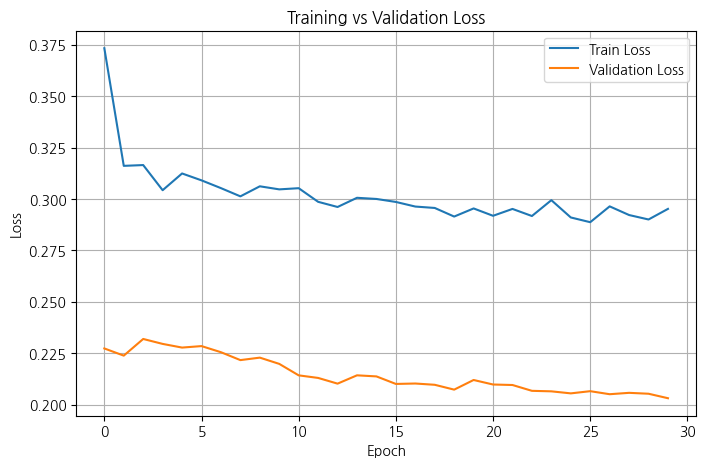

In [ ]:
# 모델 평가 그래프

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 엑셀파일로 예측값 만들기

predictions = model.predict(X_test)

predictions = scaler_y.inverse_transform(predictions)
predictions = np.round(predictions)

actual_values = y_test_target[window_size:].flatten()

print(predictions.shape)
print(actual_values.shape)

predictions = predictions.flatten()

result_df = pd.DataFrame({
    '일시': test.index[window_size:],
    'actual': actual_values,
    'predictions': predictions
})

result_df.to_excel('predictions.xlsx', index=False)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
(359, 1)
(359,)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Define the font properties
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = 'NanumGothic'

# Check if font file exists
if os.path.exists(font_path):
    # Add the font to Matplotlib's font manager directly
    fm.fontManager.addfont(font_path)
    # Set the font family globally for all plots
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # For displaying minus signs correctly

    print(f"Matplotlib font set to '{font_name}' from '{font_path}'.")
else:
    print(f"Warning: Font file not found at {font_path}. Korean characters may not display correctly.")
    print("Please ensure 'fonts-nanum' is installed and 'fc-cache -fv' has been run.")

# Verify current font settings (optional, for debugging)
print(f"Current Matplotlib font family: {plt.rcParams['font.family']}")

Matplotlib font set to 'NanumGothic' from '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'.
Current Matplotlib font family: ['NanumGothic']


In [ ]:
# 사분위수로 위험도 기준값 작성

threshold_low_p = result_df['predictions'].quantile(0.25)
threshold_medium_p = result_df['predictions'].quantile(0.50)
threshold_high_p = result_df['predictions'].quantile(0.75)

threshold_low = threshold_low_p
threshold_medium = threshold_medium_p
threshold_high = threshold_high_p

def classify_risk(power):
    if power <= threshold_low:
        return '낮음'
    elif power <= threshold_medium:
        return '보통'
    elif power <= threshold_high:
        return '높음'
    else:
        return '위험'

result_df['risk_level'] = result_df['predictions'].apply(classify_risk)

print("전력수요 예측 위험도 분류 결과:")
display(result_df.head())
display(result_df.tail())

전력수요 예측 위험도 분류 결과:


,일시,actual,predictions,risk_level
0,2024-01-08,13105.0,11097.0,위험
1,2024-01-09,13905.0,11214.0,위험
2,2024-01-10,13073.0,11205.0,위험
3,2024-01-11,13516.0,11170.0,위험
4,2024-01-12,12849.0,11112.0,위험


,일시,actual,predictions,risk_level
354,2024-12-27,12869.0,11085.0,위험
355,2024-12-28,10896.0,11128.0,위험
356,2024-12-29,9829.0,11166.0,위험
357,2024-12-30,11827.0,11144.0,위험
358,2024-12-31,12777.0,10992.0,위험


In [ ]:
# 위험도별 그룹핑

risk_level_counts = result_df['risk_level'].value_counts()
display(risk_level_counts)

,count
risk_level,
위험,90
보통,90
낮음,90
높음,89


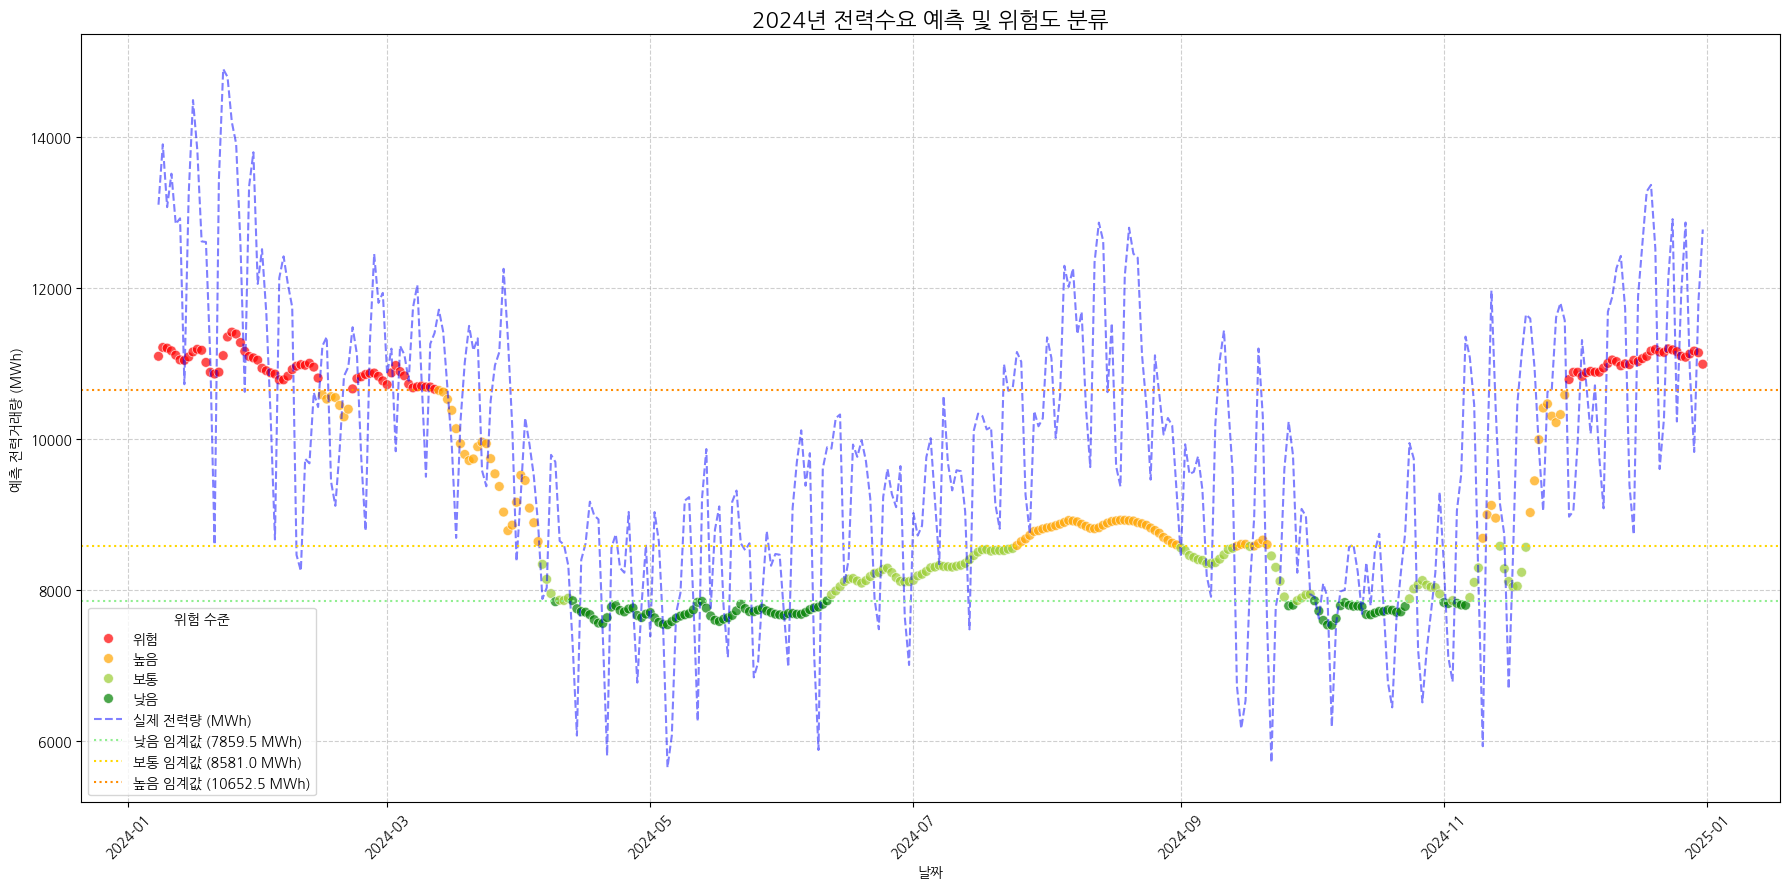

In [ ]:
# 색상 매핑

import seaborn as sns

risk_colors = {
    '낮음': 'green',
    '보통': 'yellowgreen',
    '높음': 'orange',
    '위험': 'red'
}

plt.figure(figsize=(18, 9))
sns.scatterplot(
    data=result_df,
    x='일시',
    y='predictions',
    hue='risk_level',
    palette=risk_colors,
    s=50,
    alpha=0.7
)

# 최종 그래프 그리기
plt.plot(result_df['일시'], result_df['actual'], label='실제 전력량 (MWh)', color='blue', alpha=0.5, linestyle='--')
plt.axhline(y=threshold_low, color='lightgreen', linestyle=':', label=f'낮음 임계값 ({threshold_low} MWh)')
plt.axhline(y=threshold_medium, color='gold', linestyle=':', label=f'보통 임계값 ({threshold_medium} MWh)')
plt.axhline(y=threshold_high, color='darkorange', linestyle=':', label=f'높음 임계값 ({threshold_high} MWh)')

plt.xlabel('날짜')
plt.ylabel('예측 전력거래량 (MWh)')
plt.title('2024년 전력수요 예측 및 위험도 분류', fontsize=16)
plt.legend(title='위험 수준')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()